In [1]:
pip install numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


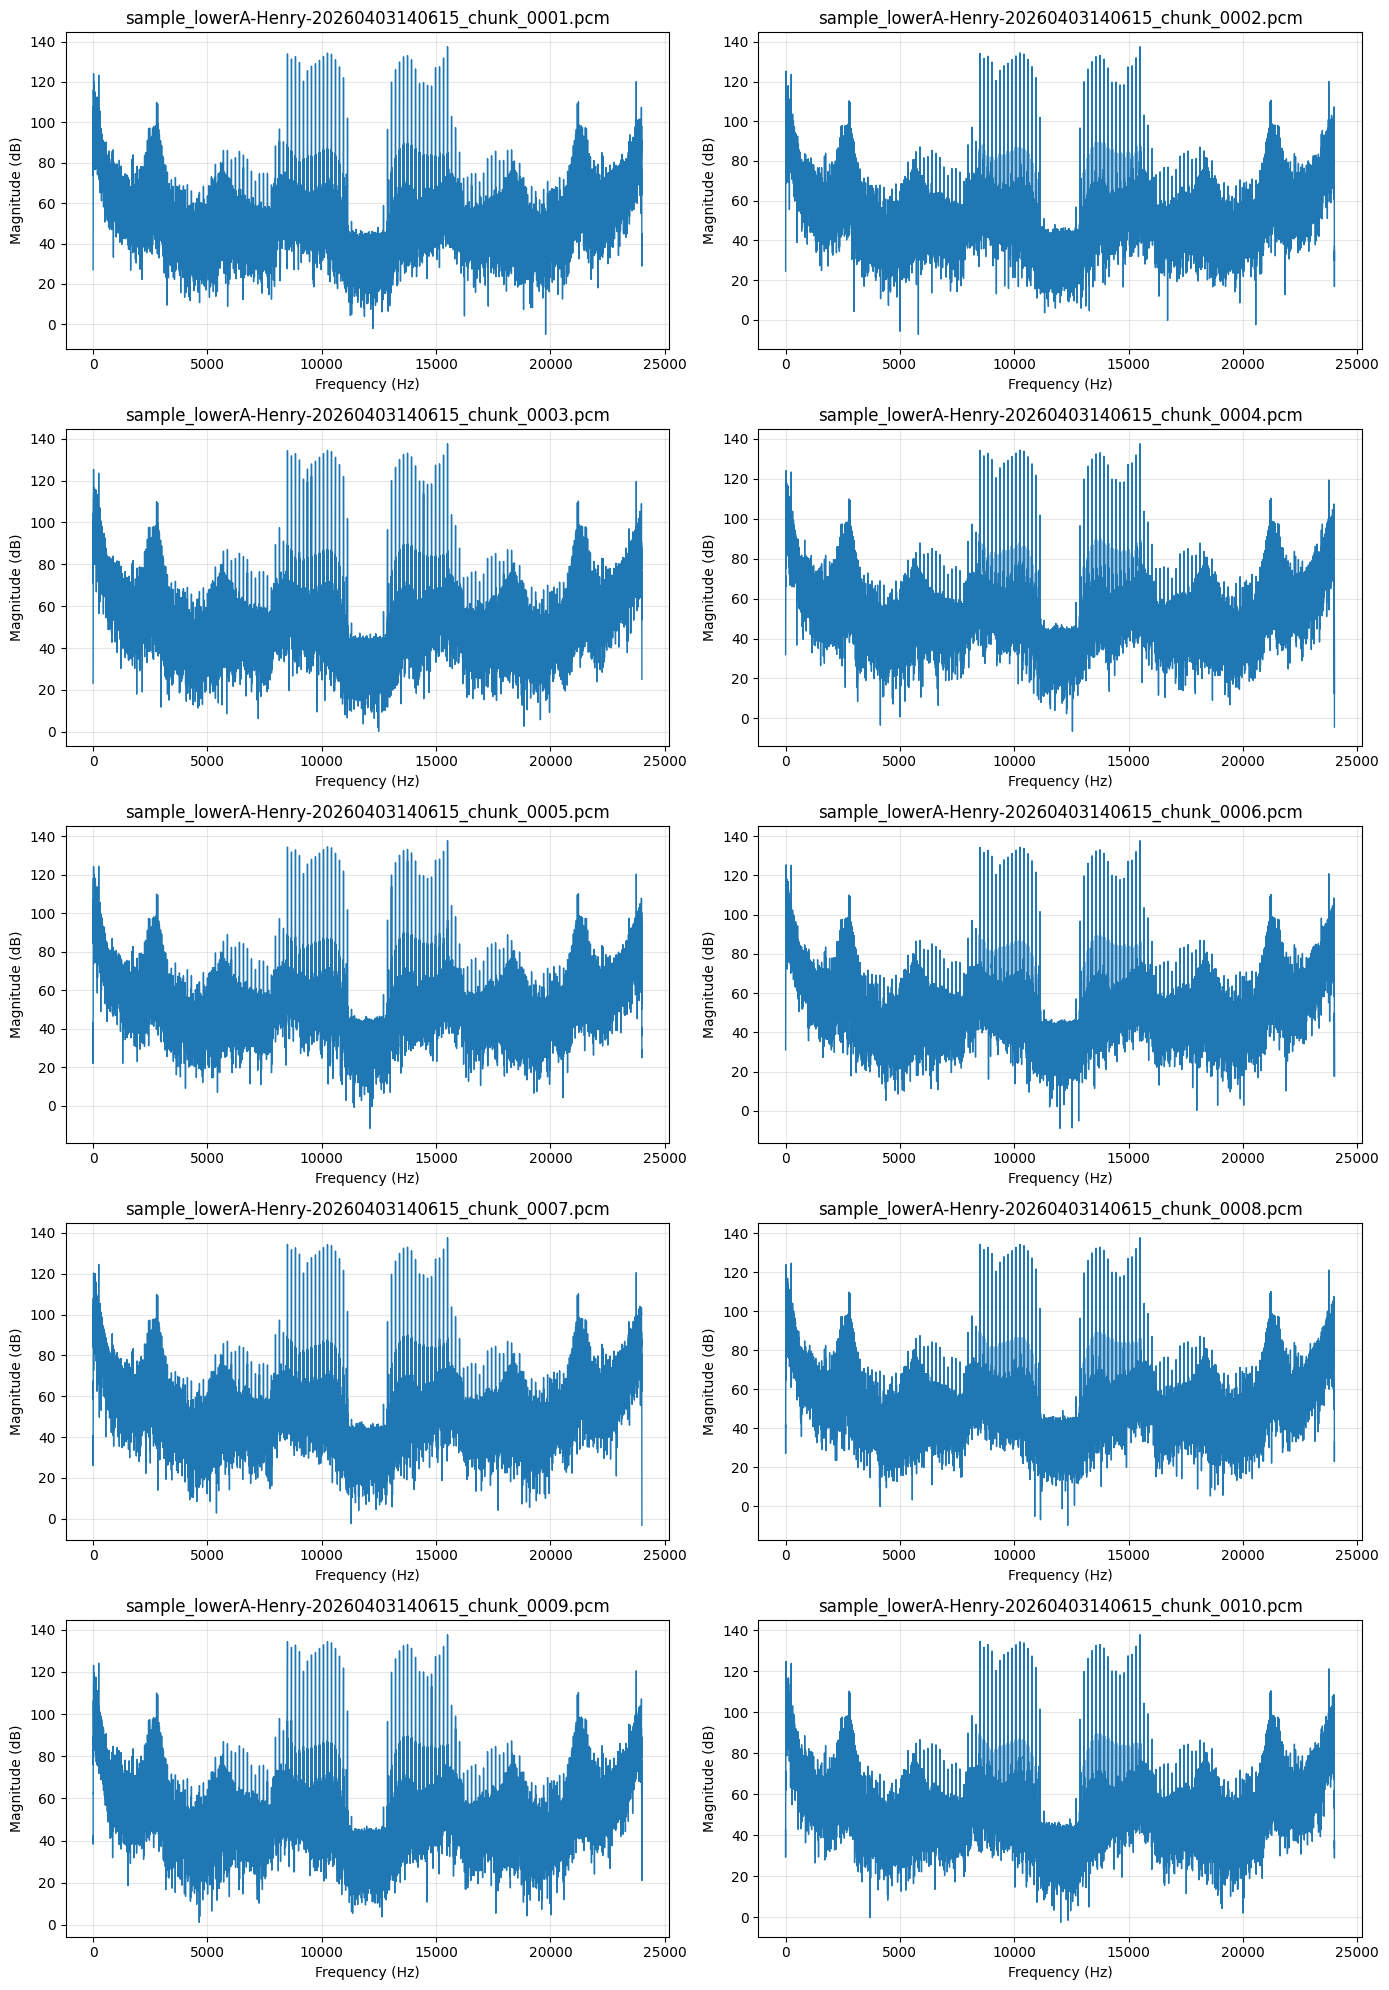

In [11]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt

def read_pcm(path: Path, dtype: np.dtype, channels: int):
    """Read raw PCM, return (full_data, mono_float32)."""
    raw = np.fromfile(path, dtype=dtype)
    if channels > 1:
        raw = raw[: raw.size - (raw.size % channels)]
        data = raw.reshape(-1, channels)
    else:
        data = raw.reshape(-1, 1)
    mono = data.mean(axis=1).astype(np.float32)
    return data, mono

# Update this if your PCM files use a different sampling rate
SAMPLE_RATE = 48000

pcm_files = sorted(Path("data/chunked").glob("*.pcm"))

if not pcm_files:
    print("No .pcm files found in data/chunked")
else:
    n = len(pcm_files)
    cols = 2
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)
    axes = axes.flatten()

    for i, pcm_path in enumerate(pcm_files):
        signal = np.fromfile(pcm_path, dtype=np.int16)

        ax = axes[i]
        if signal.size == 0:
            ax.set_title(f"{pcm_path.name} (empty)")
            ax.axis("off")
            continue

        # FFT spectrum
        windowed = signal.astype(np.float32) * np.hanning(signal.size)
        spectrum = np.fft.rfft(windowed)
        freqs = np.fft.rfftfreq(signal.size, d=1.0 / SAMPLE_RATE)
        magnitude_db = 20 * np.log10(np.abs(spectrum) + 1e-12)

        ax.plot(freqs, magnitude_db, linewidth=1)
        ax.set_title(pcm_path.name)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Magnitude (dB)")
        ax.grid(True, alpha=0.3)

    # Hide unused subplot slots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

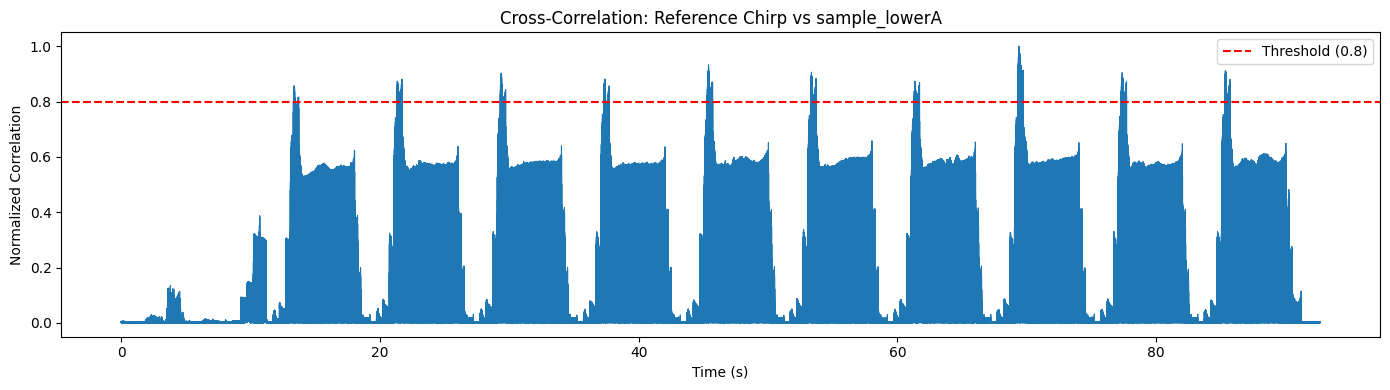

In [13]:
import matplotlib.pyplot as plt

# Parameters
sample_rate = 48000
channels = 2
dtype = np.int16

# Load reference chirp (mono)
_, ref_mono = read_pcm(Path("data/chirp.pcm"), dtype=dtype, channels=1)

# Load sample audio (stereo -> mono)
_, sample_mono = read_pcm(Path("data/henry/sample_lowerA-Henry-20260403140615.pcm"), dtype=dtype, channels=channels)

# Normalize
ref = ref_mono / (np.linalg.norm(ref_mono) + 1e-12)
sig = sample_mono / (np.max(np.abs(sample_mono)) + 1e-12)

# Cross-correlation
corr = np.correlate(sig, ref, mode='valid') / len(ref)
corr = np.abs(corr)
corr /= (np.max(corr) + 1e-12)

# Time axis
time_axis = np.arange(len(corr)) / sample_rate

# Plot
plt.figure(figsize=(14, 4))
plt.plot(time_axis, corr, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Normalized Correlation")
plt.title("Cross-Correlation: Reference Chirp vs sample_lowerA")
plt.axhline(y=0.8, color='r', linestyle='--', label='Threshold (0.8)')
plt.legend()
plt.tight_layout()
plt.show()

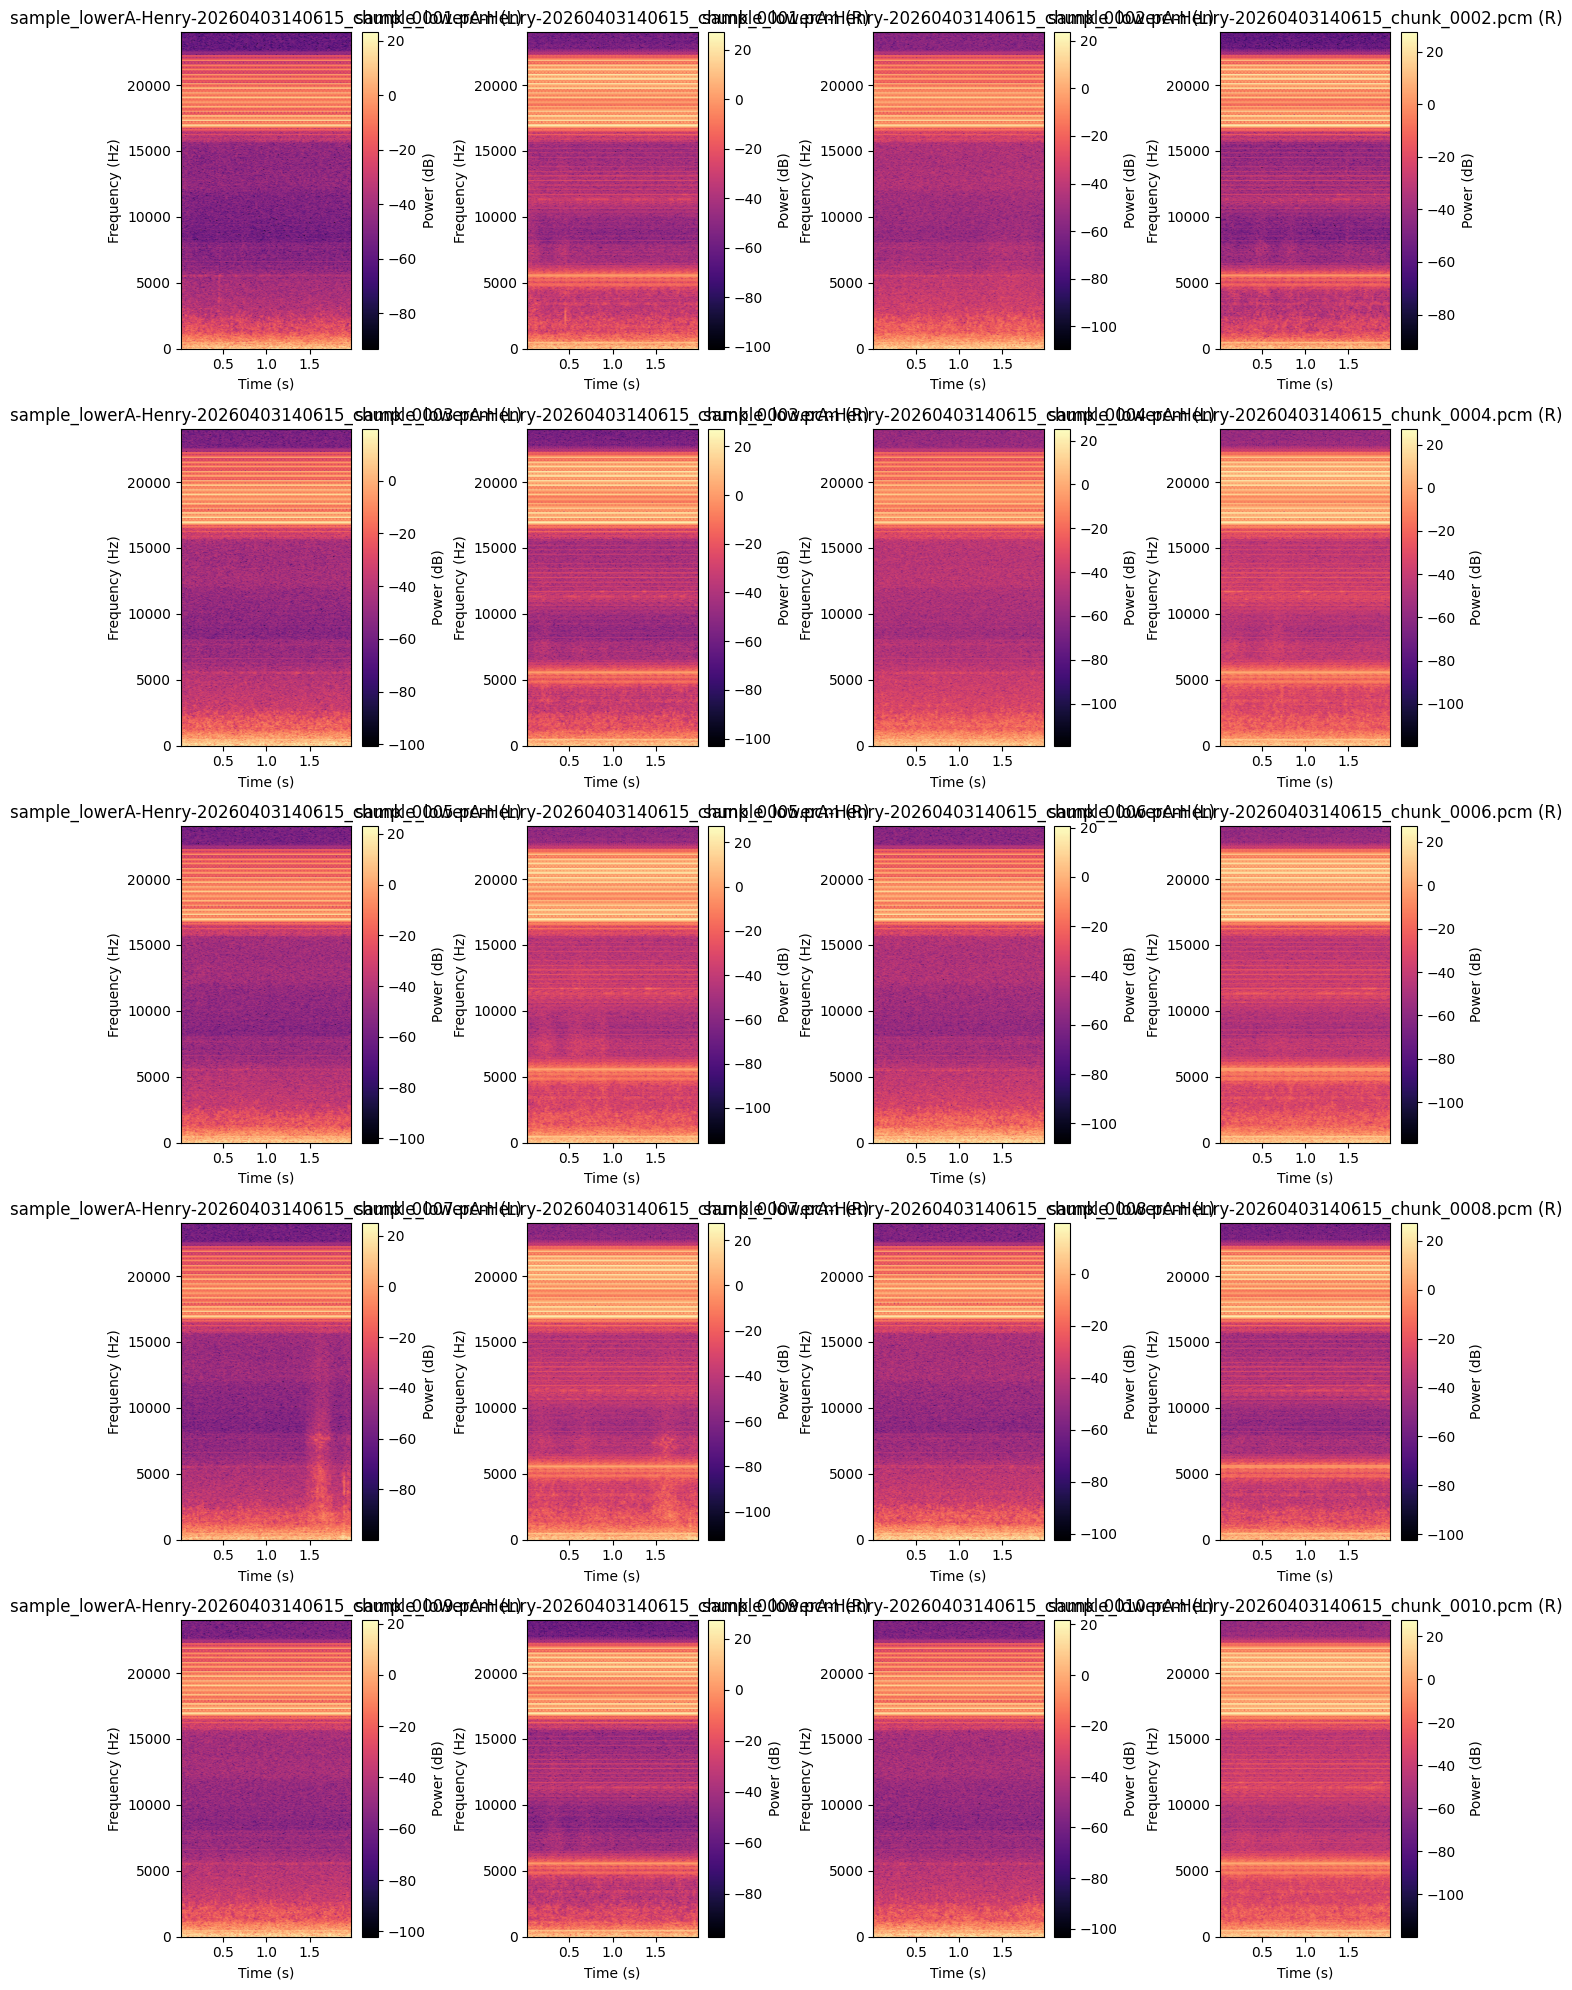

In [9]:
from scipy.signal import spectrogram

fig2, axes2 = plt.subplots(rows, cols * 2, figsize=(14, 4 * rows), squeeze=False)
axes2 = axes2.flatten()

for i, pcm_path in enumerate(pcm_files):
	raw = np.fromfile(pcm_path, dtype=np.int16).astype(np.float32)
	# Deinterleave stereo channels
	left = raw[0::2]
	right = raw[1::2]

	for ch_idx, (ch_data, ch_label) in enumerate([(left, "L"), (right, "R")]):
		ax = axes2[i * 2 + ch_idx]

		if ch_data.size == 0:
			ax.set_title(f"{pcm_path.name} {ch_label} (empty)")
			ax.axis("off")
			continue

		f, t, Sxx = spectrogram(ch_data, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
		Sxx_db = 10 * np.log10(Sxx + 1e-12)

		im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='magma')
		ax.set_title(f"{pcm_path.name} ({ch_label})")
		ax.set_xlabel("Time (s)")
		ax.set_ylabel("Frequency (Hz)")
		fig2.colorbar(im, ax=ax, label="Power (dB)")

for j in range(n * 2, len(axes2)):
	axes2[j].axis("off")

plt.tight_layout()
plt.show()